<a href="https://colab.research.google.com/github/msiplab/EicEngLabIV/blob/master/example01_01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 実験Ⅳ－１　多項式回帰モデル

1. 実習データの読み込み
1. 線形単回帰の実行
1. 多項式単回帰の実行



In [17]:
!pip install japanize-matplotlib
%matplotlib inline

import warnings
warnings.simplefilter('ignore') #警告を無視（コメントアウト推奨）

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import japanize_matplotlib #日本語化matplotlib
sns.set(font="IPAexGothic") #日本語フォント設定


## Colab向け: セル内に観測データを直接定義

ファイルアップロードなしで実行できるように、観測データをノート内に直接記述します。

In [18]:
# ファイルをアップロードする
#from google.colab import files
#uploaded_file = files.upload()
#filename = next(iter(uploaded_file))
#print(filename)

# URLを指定する
# filename = 'https://...'

In [19]:
# 観測データ（practice01_09.csv の室温列）をセル内に直接定義
energy = [2.5, 2.510121457, 2.520325203, 2.530612245, 2.540983607, 2.551440329, 2.561983471, 2.572614108, 2.583333333, 2.594142259, 2.605042017, 2.616033755, 2.627118644, 2.638297872, 2.64957265, 2.660944206, 2.672413793, 2.683982684, 2.695652174, 2.707423581, 2.719298246, 2.731277533, 2.743362832, 2.755555556, 2.767857143, 2.780269058, 2.792792793, 2.805429864, 2.818181818, 2.831050228, 2.844036697, 2.857142857, 2.87037037, 2.88372093, 2.897196262, 2.910798122, 2.924528302, 2.938388626, 2.952380952, 2.966507177, 2.980769231, 2.995169082, 3.009708738, 3.024390244, 3.039215686, 3.054187192, 3.069306931, 3.084577114, 3.1, 3.115577889, 3.131313131, 3.147208122, 3.163265306, 3.179487179, 3.195876289, 3.212435233, 3.229166667, 3.246073298, 3.263157895, 3.28042328, 3.29787234, 3.315508021, 3.333333333, 3.351351351, 3.369565217, 3.387978142, 3.406593407, 3.425414365, 3.444444444, 3.463687151, 3.483146067, 3.502824859, 3.522727273, 3.542857143, 3.563218391, 3.583815029, 3.604651163, 3.625730994, 3.647058824, 3.668639053, 3.69047619, 3.71257485, 3.734939759, 3.757575758, 3.780487805, 3.803680982, 3.827160494, 3.850931677, 3.875, 3.899371069, 3.924050633, 3.949044586, 3.974358974, 4, 4.025974026, 4.052287582, 4.078947368, 4.105960265, 4.133333333, 4.161073826, 4.189189189, 4.217687075, 4.246575342, 4.275862069]
alpha_e2_room = [5.42687E-07, 4.94451E-07, 3.99887E-07, 3.21315E-07, 2.80854E-07, 2.09476E-07, 1.63707E-07, 1.5604E-07, 1.09053E-07, 8.03665E-08, 5.67361E-08, 5.15215E-08, 4.71278E-08, 2.73531E-08, 2.71372E-08, 2.14284E-08, 2.1583E-08, 2.35346E-08, 2.01797E-08, 3.64636E-08, 3.15549E-08, 4.38557E-08, 5.7837E-08, 6.53713E-08, 7.02285E-08, 8.47083E-08, 1.02872E-07, 1.01477E-07, 1.33493E-07, 1.3951E-07, 1.18272E-07, 1.23453E-07, 1.13029E-07, 8.2811E-08, 7.35826E-08, 3.53668E-08, 8.35003E-09, 3.36931E-10, 2.40114E-09, 4.87453E-08, 1.80713E-07, 4.0831E-07, 7.73325E-07, 1.30542E-06, 1.95417E-06, 3.15377E-06, 4.36976E-06, 6.38247E-06, 8.45539E-06, 1.14287E-05, 1.50364E-05, 1.92494E-05, 2.44765E-05, 3.03411E-05, 3.74178E-05, 4.6184E-05, 5.53177E-05, 6.7587E-05, 8.15465E-05, 9.91944E-05, 0.00012092, 0.000147952, 0.000181774, 0.000202352, 0.000275068, 0.000334612, 0.000413773, 0.00050495, 0.000615271, 0.000742832, 0.000885402, 0.001045238, 0.001216047, 0.001400143, 0.00158931, 0.001788767, 0.001994459, 0.00220529, 0.002386267, 0.002556618, 0.002733571, 0.002917272, 0.003089402, 0.003257002, 0.003427672, 0.003558575, 0.003690035, 0.003817043, 0.003966408, 0.004098815, 0.004250917, 0.004362893, 0.00450438, 0.00463322, 0.004725561, 0.004912728, 0.004992583, 0.005164728, 0.005256373, 0.0053965, 0.005495774, 0.005527507, 0.005526651, 0.005588508]

dataset = pd.DataFrame({
    'エネルギー[eV]': energy,
    '(αE)^2_室温[(eV/cm)^2]': alpha_e2_room
})

# データの表示
display(dataset)

# 観測データ数
nSamples = len(dataset)

,エネルギー[eV],(αE)^2_室温[(eV/cm)^2]
0,2.500000,5.426870e-07
1,2.510121,4.944510e-07
2,2.520325,3.998870e-07
3,2.530612,3.213150e-07
4,2.540984,2.808540e-07
...,...,...
99,4.161074,5.396500e-03
100,4.189189,5.495774e-03
101,4.217687,5.527507e-03
102,4.246575,5.526651e-03


In [20]:
# 説明変数の設定
x = dataset.iloc[:,0].values.reshape(-1,1) 
#display(x)

# 目的変数の設定
y = dataset.iloc[:,1].values.reshape(-1,1)
#display(y)

## 観測データの散布図


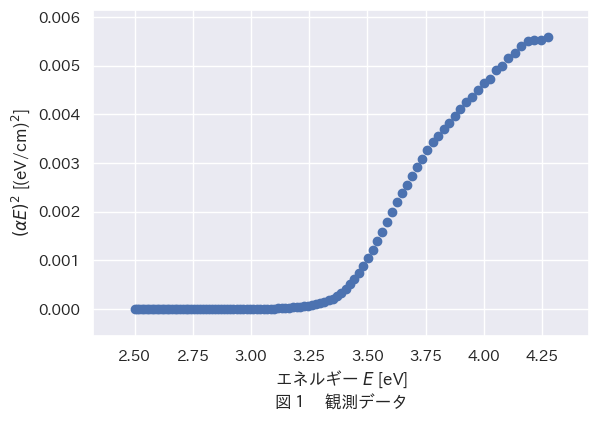

In [21]:
# 散布図の範囲情報の抽出
minx = np.min(x)
maxx = np.max(x)
rx = maxx-minx
cx = 0.5*rx
miny = np.min(y)
maxy = np.max(y)
ry = maxy-miny
cy = 0.5*ry

# 散布図の表示
fig, ax = plt.subplots()
ax.scatter(x,y)
ax.set_xlabel(r'エネルギー $E$ [eV]')
ax.set_ylabel(r'$(\alpha E)^2$ [(eV/cm)$^2$]')
ax.text(0.5, -0.18, "図１　観測データ", transform=ax.transAxes, ha='center', va='top')
ax.set_xlim([minx-0.1*rx,maxx+0.1*rx])
ax.set_ylim([miny-0.1*ry,maxy+0.1*ry])
ax.grid(True)
plt.subplots_adjust(bottom=0.2)
plt.show()

## 線形単回帰の実行

In [22]:
from sklearn.linear_model import LinearRegression

# 線形単回帰のインスタンス生成
regu = LinearRegression()

# 線形単回帰分析
regu.fit(x,y)

LinearRegression()

β₀ = -0.01 
β₁ =  0.00 
線形単回帰式: ŷ = -9.354546e-03 + (3.269149e-03)x


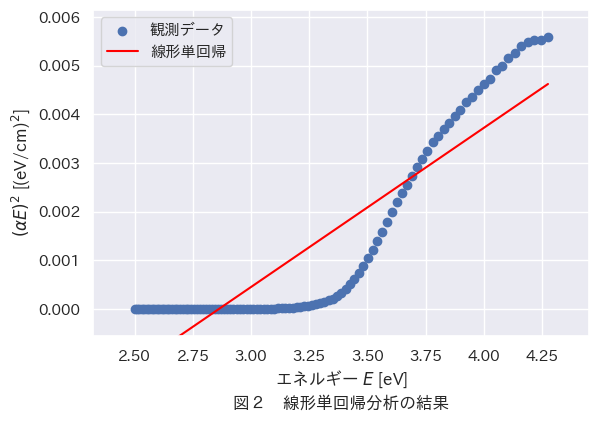

In [35]:
# 推定結果
beta0 = regu.intercept_[0]
beta1 = regu.coef_[0][0]
print("β₀ = {0:5.2f} ".format(beta0))
print("β₁ = {0:5.2f} ".format(beta1))
print(f"線形単回帰式: ŷ = {beta0:.6e} + ({beta1:.6e})x")

# 回帰直線をプロット
fig, ax = plt.subplots()
xfit = np.linspace(minx,maxx,nSamples).reshape(-1,1) # 列ベクトル化
yfit = regu.predict(xfit)
ax.scatter(x, y, color='#4C72B0', label='観測データ')
ax.plot(xfit, yfit, color='red', label='線形単回帰')
ax.set_xlabel(r'エネルギー $E$ [eV]')
ax.set_ylabel(r'$(\alpha E)^2$ [(eV/cm)$^2$]')
ax.text(0.5, -0.18, "図２　線形単回帰分析の結果", transform=ax.transAxes, ha='center', va='top')
ax.set_xlim([minx-0.1*rx,maxx+0.1*rx])
ax.set_ylim([miny-0.1*ry,maxy+0.1*ry])
ax.grid(True)
ax.legend(loc='best')
plt.subplots_adjust(bottom=0.2)
plt.show()

## 多項式単回帰モデルの次数の選択


deg = 1: AIC = -1.17e+03 
deg = 2: AIC = -1.37e+03 
deg = 3: AIC = -1.38e+03 
deg = 4: AIC = -1.55e+03 
deg = 5: AIC = -1.55e+03 
deg = 6: AIC = -1.66e+03 
deg = 7: AIC = -1.65e+03 
deg = 8: AIC = -1.77e+03 
deg = 9: AIC = -1.80e+03 
deg = 10: AIC = -1.79e+03 
deg = 11: AIC = -1.79e+03 
deg = 12: AIC = -1.79e+03 
deg = 13: AIC = -1.79e+03 
deg = 14: AIC = -1.80e+03 
deg = 15: AIC = -1.82e+03 
deg = 16: AIC = -1.83e+03 
deg = 17: AIC = -1.85e+03 
deg = 18: AIC = -1.86e+03 
deg = 19: AIC = -1.87e+03 
deg = 20: AIC = -1.86e+03 
deg = 21: AIC = -1.85e+03 
deg = 22: AIC = -1.84e+03 
deg = 23: AIC = -1.83e+03 
deg = 24: AIC = -1.82e+03 
deg = 25: AIC = -1.82e+03 
deg = 26: AIC = -1.82e+03 
deg = 27: AIC = -1.79e+03 
deg = 28: AIC = -1.77e+03 
deg = 29: AIC = -1.77e+03 
deg = 30: AIC = -1.76e+03 


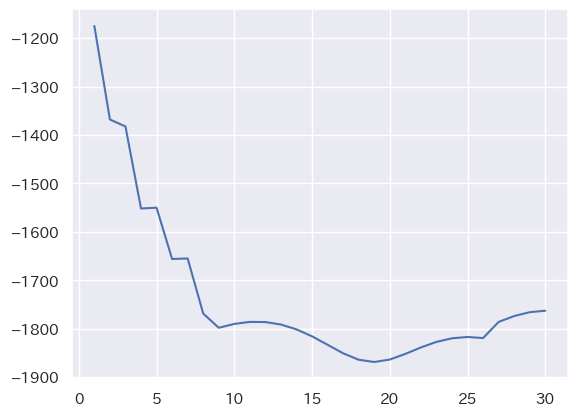

In [24]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error

maxdeg = 30
deg = np.zeros(maxdeg,dtype=int)
aic = np.zeros(maxdeg)
regp = [ [] for idx in range(maxdeg) ]
for idx in range(maxdeg):
    deg[idx] = idx+1
    # 多項式単回帰のインスタンス生成
    regp[idx] = make_pipeline(PolynomialFeatures(degree=deg[idx],include_bias=False),
                         LinearRegression())
    # 多項式単回帰分析
    regp[idx].fit(x,y)

    # AIC
    ypred = regp[idx].predict(x)
    mse = mean_squared_error(y,ypred)
    aic[idx] = nSamples*np.log(2*np.pi*mse)+nSamples+2*(deg[idx]+2)
    print("deg = {0:d}: AIC = {1:5.2e} ".format(deg[idx],aic[idx]))

# AICのプロット
fig, ax = plt.subplots()
ax.plot(deg,aic)
plt.show()


In [25]:
# 最小のAICを与える次数
degopt = deg[np.argmin(aic)]
print(f"AIC最小次数 degopt = {degopt}")
print(f"AIC最小値 = {np.min(aic):.6e}")

# 多項式単回帰のインスタンス生成
regpopt = regp[np.argmin(aic)]

AIC最小次数 degopt = 19
AIC最小値 = -1.868689e+03


β₀ = -5.09e-02 
β₁ = 1.79e-05 
β₂ = 6.20e-05 
β₃ = 1.52e-04 
β₄ = 3.08e-04 
β₅ = 5.31e-04 
β₆ = 7.68e-04 
β₇ = 8.80e-04 
β₈ = 6.61e-04 
β₉ = 1.84e-05 
β₁₀ = -7.03e-04 
β₁₁ = -6.67e-04 
β₁₂ = 4.30e-04 
β₁₃ = 7.90e-04 
β₁₄ = -9.60e-04 
β₁₅ = 4.70e-04 
β₁₆ = -1.27e-04 
β₁₇ = 2.01e-05 
β₁₈ = -1.74e-06 
β₁₉ = 6.42e-08 
多項式回帰式: ŷ = -5.092366e-02 + (1.791270e-05)x_1 + (6.204170e-05)x_2 + (1.520609e-04)x_3 + (3.078083e-04)x_4 + (5.305812e-04)x_5 + (7.682213e-04)x_6 + (8.800884e-04)x_7 + (6.609720e-04)x_8 + (1.838531e-05)x_9 + (-7.031486e-04)x_10 + (-6.666483e-04)x_11 + (4.297419e-04)x_12 + (7.895386e-04)x_13 + (-9.598270e-04)x_14 + (4.698994e-04)x_15 + (-1.274054e-04)x_16 + (2.011792e-05)x_17 + (-1.741958e-06)x_18 + (6.424063e-08)x_19


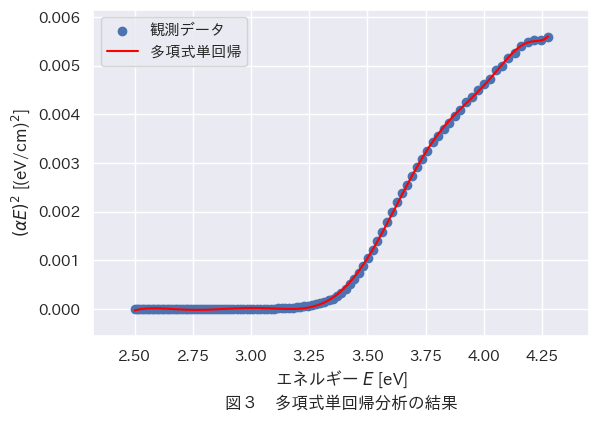

In [36]:
# 推定結果
from turtle import color


beta0 = regpopt[1].intercept_[0]
coefs = regpopt[1].coef_[0]
sub_map = str.maketrans("0123456789", "₀₁₂₃₄₅₆₇₈₉")
print("β₀ = {0:5.2e} ".format(beta0))
for idx in range(0,degopt):
    sub_idx = str(idx+1).translate(sub_map)
    print("β{0} = {1:5.2e} ".format(sub_idx, coefs[idx]))

equation_terms = [f"{beta0:.6e}"] + [f"({coefs[idx]:.6e})x_{idx+1}" for idx in range(degopt)]
print("多項式回帰式: ŷ = " + " + ".join(equation_terms))

# 回帰曲線をプロット
fig, ax = plt.subplots()
yfit = regpopt.predict(xfit)
ax.scatter(x, y, color='#4C72B0', label='観測データ')
ax.plot(xfit, yfit, color='red', label='多項式単回帰')
ax.set_xlabel(r'エネルギー $E$ [eV]')
ax.set_ylabel(r'$(\alpha E)^2$ [(eV/cm)$^2$]')
ax.text(0.5, -0.18, "図３　多項式単回帰分析の結果", transform=ax.transAxes, ha='center', va='top')
ax.set_xlim([minx-0.1*rx,maxx+0.1*rx])
ax.set_ylim([miny-0.1*ry,maxy+0.1*ry])
ax.grid(True)
ax.legend(loc='best')
plt.subplots_adjust(bottom=0.2)
plt.show()

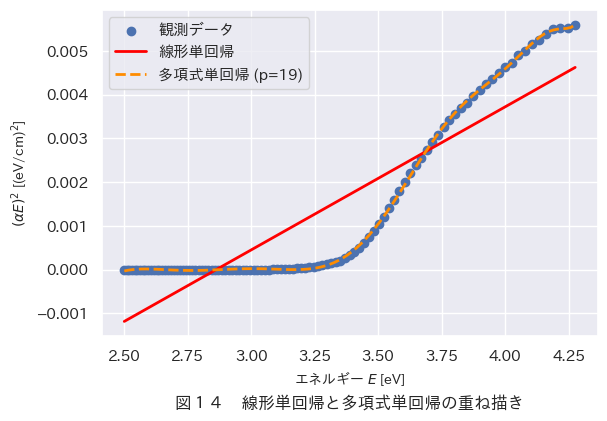

In [41]:
# 観測データ・線形単回帰・多項式単回帰を1枚に重ねて表示
fig, ax = plt.subplots()

# 予測曲線（線形・多項式）
yfit_lin = regu.predict(xfit)
yfit_poly = regpopt.predict(xfit)

# 描画
ax.scatter(x, y, color='#4C72B0', label='観測データ')
ax.plot(xfit, yfit_lin, color='red', linewidth=2, label='線形単回帰')
ax.plot(xfit, yfit_poly, color='darkorange', linewidth=2, linestyle='--', label='多項式単回帰 (p=19)')

# 軸ラベル・タイトル（下側）
ax.set_xlabel(r'エネルギー $E$ [eV]', fontsize=10)
ax.set_ylabel(r'$(\alpha E)^2$ [(eV/cm)$^2$]', fontsize=10)
ax.text(0.5, -0.18, '図１４　線形単回帰と多項式単回帰の重ね描き',
        transform=ax.transAxes, ha='center', va='top')

ax.legend(loc='best')
plt.subplots_adjust(bottom=0.2)
plt.show()